# Monte Carlo Integration — Estimating π from Random Raindrops
## *The simplest possible Monte Carlo integral, and what it teaches us*

Draw a 1×1 square. Place the centre of a circle of radius 1 at one corner — so one quarter of the circle lies inside the square.

Now let it rain. Raindrops fall uniformly at random across the square. A drop lands inside the quarter-circle if its distance from the corner is less than 1.

The ratio of drops inside the quarter-circle to total drops converges to π/4 — and multiplying by 4 gives π.

This is Monte Carlo integration in its purest form: **estimate an area by counting random points.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

np.random.seed(42)

---
## The Geometry

A raindrop at position (x, y) is inside the quarter-circle if:
$$x^2 + y^2 \leq 1$$

Area of the square = 1. Area of the quarter-circle = π/4.

Therefore:
$$\frac{\text{drops inside}}{\text{total drops}} \xrightarrow{N \to \infty} \frac{\pi/4}{1} = \frac{\pi}{4}$$

$$\pi \approx 4 \times \frac{\text{drops inside}}{\text{total drops}}$$

In [2]:
N = 100_000

x = np.random.uniform(0, 1, N)
y = np.random.uniform(0, 1, N)

inside = (x**2 + y**2) <= 1.0

pi_estimate = 4 * inside.sum() / N

print(f"Total raindrops     : {N:,}")
print(f"Inside quarter-circle: {inside.sum():,}  ({inside.mean():.4%})")
print(f"π estimate          : {pi_estimate:.6f}")
print(f"True π              : {np.pi:.6f}")
print(f"Error               : {abs(pi_estimate - np.pi):.6f}  ({abs(pi_estimate - np.pi)/np.pi:.4%})")

Total raindrops     : 100,000
Inside quarter-circle: 78,440  (78.4400%)
π estimate          : 3.137600
True π              : 3.141593
Error               : 0.003993  (0.1271%)


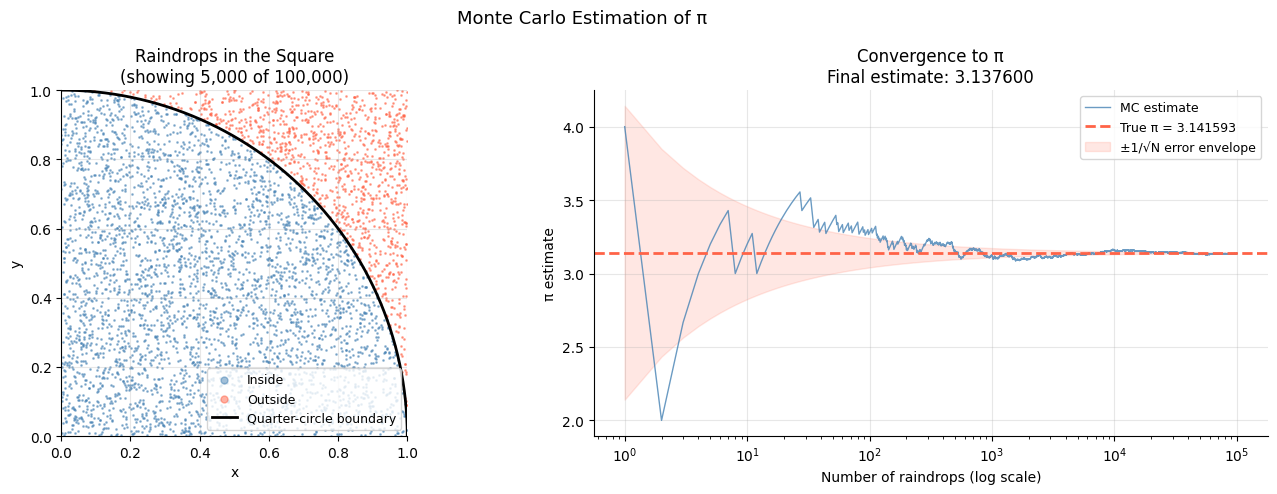

In [3]:
# Visualise the raindrops
n_plot = 5000  # plot a subset for clarity

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: scatter plot of raindrops
axes[0].scatter(x[:n_plot][ inside[:n_plot]], y[:n_plot][ inside[:n_plot]],
                s=1, color='steelblue', alpha=0.5, label='Inside')
axes[0].scatter(x[:n_plot][~inside[:n_plot]], y[:n_plot][~inside[:n_plot]],
                s=1, color='tomato',    alpha=0.5, label='Outside')
theta = np.linspace(0, np.pi/2, 300)
axes[0].plot(np.cos(theta), np.sin(theta), 'k-', lw=2, label='Quarter-circle boundary')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect('equal')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title(f'Raindrops in the Square\n(showing {n_plot:,} of {N:,})')
axes[0].legend(fontsize=9, markerscale=5)

# Panel 2: convergence of π estimate with N
n_values = np.logspace(1, 5, 200).astype(int)
pi_running = 4 * np.cumsum(inside) / np.arange(1, N + 1)

axes[1].semilogx(np.arange(1, N + 1), pi_running,
                 color='steelblue', lw=1, alpha=0.8, label='MC estimate')
axes[1].axhline(np.pi, color='tomato', lw=2, linestyle='--', label=f'True π = {np.pi:.6f}')
axes[1].fill_between(np.arange(1, N + 1),
                     np.pi - 1/np.sqrt(np.arange(1, N + 1)),
                     np.pi + 1/np.sqrt(np.arange(1, N + 1)),
                     alpha=0.15, color='tomato', label='±1/√N error envelope')
axes[1].set_xlabel('Number of raindrops (log scale)')
axes[1].set_ylabel('π estimate')
axes[1].set_title(f'Convergence to π\nFinal estimate: {pi_estimate:.6f}')
axes[1].legend(fontsize=9)

plt.suptitle('Monte Carlo Estimation of π', fontsize=13)
plt.tight_layout()
plt.savefig('monte_carlo_pi.png', dpi=150)
plt.show()

---
## Convergence Rate

The Monte Carlo error scales as **1/√N**. To gain one extra decimal place of precision you need 100× more samples. This slow convergence is the fundamental limitation of Monte Carlo integration — but it is also **dimension-independent**, which is its great strength.

For high-dimensional integrals where grid-based methods scale exponentially with dimension, Monte Carlo's 1/√N convergence becomes the only practical option. This is why Monte Carlo methods are indispensable in particle physics, financial modelling, and Bayesian inference.

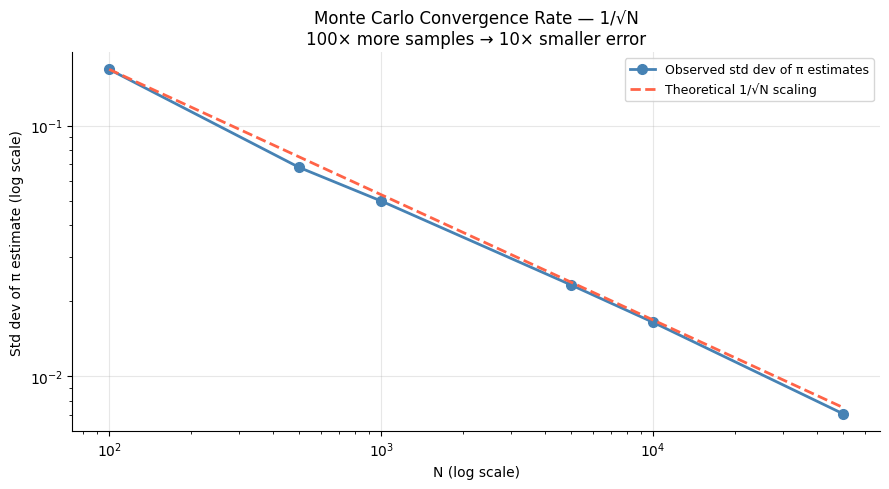

       N      Std dev       1/√N
--------------------------------
     100     0.167632   0.100000
     500     0.068068   0.044721
   1,000     0.050024   0.031623
   5,000     0.023115   0.014142
  10,000     0.016408   0.010000
  50,000     0.007077   0.004472


In [4]:
# Demonstrate the 1/sqrt(N) convergence empirically
# Run 200 independent simulations at each N and measure the std dev of π estimates

sample_sizes = [100, 500, 1000, 5000, 10000, 50000]
n_repeats    = 200
std_devs     = []

for n in sample_sizes:
    estimates = []
    for _ in range(n_repeats):
        x_ = np.random.uniform(0, 1, n)
        y_ = np.random.uniform(0, 1, n)
        estimates.append(4 * ((x_**2 + y_**2) <= 1).mean())
    std_devs.append(np.std(estimates))

std_devs  = np.array(std_devs)
n_array   = np.array(sample_sizes)
theory    = 1 / np.sqrt(n_array)  # theoretical 1/sqrt(N) scaling
theory   *= std_devs[0] / theory[0]  # rescale to match observed magnitude

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(n_array, std_devs, 'o-', color='steelblue', lw=2, ms=7, label='Observed std dev of π estimates')
ax.loglog(n_array, theory,   '--', color='tomato',    lw=2,       label='Theoretical 1/√N scaling')
ax.set_xlabel('N (log scale)')
ax.set_ylabel('Std dev of π estimate (log scale)')
ax.set_title('Monte Carlo Convergence Rate — 1/√N\n100× more samples → 10× smaller error')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('convergence_rate.png', dpi=150)
plt.show()

print(f"{'N':>8} {'Std dev':>12} {'1/√N':>10}")
print("-" * 32)
for n, sd in zip(sample_sizes, std_devs):
    print(f"{n:>8,} {sd:>12.6f} {1/np.sqrt(n):>10.6f}")

---
## Summary

Monte Carlo integration estimates areas (and integrals) by sampling random points and counting how many satisfy a geometric condition. The estimate converges to the true value at a rate of **1/√N** — slow, but dimension-independent.

This π estimation is the simplest possible case. The same principle extends directly to:
- Sampling arbitrary probability distributions (see `monte_carlo_sampling_methods.ipynb`)
- Numerical integration in high-dimensional spaces where grid-based methods are intractable
- Bayesian posterior estimation via MCMC
- Risk and uncertainty quantification in engineering and finance